# 🎙️ Clasificación de Emociones en Voz con Transformer
### Dataset: RAVDESS | Modelo: Transformer adaptado a Audio

**Idea central:** Igual que en MNIST dividíamos la imagen en *patches* (tokens visuales),  
aquí dividimos el **Mel Spectrogram** del audio en *franjas de tiempo* (tokens temporales).  
El Transformer aplica MultiHead-Attention sobre esa secuencia para capturar patrones emocionales.

```
Audio WAV  →  Mel Spectrogram (128 × T)  →  16 franjas de tiempo  →  Transformer  →  8 emociones
```

| Elemento MNIST       | Equivalente en Audio        |
|----------------------|-----------------------------|
| Imagen 28×28         | Mel Spectrogram 128×128     |
| 16 patches de 7×7    | 16 franjas temporales       |
| Cada patch = 49 feat | Cada franja = 128 mel bins  |
| 10 clases (dígitos)  | 8 clases (emociones)        |

## 📦 1. Instalación de dependencias

In [ ]:
!pip install librosa pytorch-lightning kaggle -q

## 📥 2. Descarga del Dataset RAVDESS desde Kaggle

**Pasos previos (una sola vez):**
1. Ve a https://www.kaggle.com/settings → API → *Create New Token*
2. Descarga el archivo `kaggle.json`
3. Súbelo a tu entorno (Colab o local) y ejecuta la celda siguiente

In [1]:
# ── Opción A: Google Colab ──────────────────────────────────────────────────
# from google.colab import files
# files.upload()   # sube tu kaggle.json aquí

# ── Configurar credenciales ─────────────────────────────────────────────────
import os

# Si usas Colab:
# os.makedirs('/root/.config/kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
# os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# Si usas local (el kaggle.json ya está en ~/.kaggle/):
# No necesitas hacer nada extra

# ── Descargar dataset ───────────────────────────────────────────────────────
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio --unzip -p ./ravdess_data
print("✅ Dataset descargado correctamente")

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0

✅ Dataset descargado correctamente



  0%|          | 0.00/429M [00:00<?, ?B/s]
  0%|          | 1.00M/429M [00:00<04:44, 1.58MB/s]
  0%|          | 2.00M/429M [00:00<02:27, 3.03MB/s]
  1%|          | 3.00M/429M [00:00<01:40, 4.47MB/s]
  1%|          | 5.00M/429M [00:01<01:01, 7.28MB/s]
  2%|▏         | 7.00M/429M [00:01<00:49, 8.90MB/s]
  2%|▏         | 9.00M/429M [00:01<00:42, 10.4MB/s]
  3%|▎         | 11.0M/429M [00:01<00:38, 11.5MB/s]
  3%|▎         | 13.0M/429M [00:01<00:36, 11.9MB/s]
  3%|▎         | 15.0M/429M [00:02<01:02, 6.96MB/s]
  4%|▍         | 18.0M/429M [00:02<00:50, 8.50MB/s]
  5%|▍         | 20.0M/429M [00:02<00:43, 9.96MB/s]
  5%|▌         | 22.0M/429M [00:02<00:48, 8.86MB/s]
  6%|▌         | 24.0M/429M [00:03<00:40, 10.4MB/s]
  6%|▌         | 26.0M/429M [00:03<00:42, 9.88MB/s]
  7%|▋         | 28.0M/429M [00:03<00:41, 10.2MB/s]
  7%|▋         | 30.0M/429M [00:03<00:37, 11.0MB/s]
  7%|▋         | 32.0M/429M [00:03<00:38, 10.8MB/s]
  8%|▊         | 34.0M/429M [00:03<00:38, 10.8MB/s]
  8%|▊         | 36.

## 🔍 3. Exploración del Dataset

In [5]:
import os
import glob

# Buscar todos los archivos WAV
wav_files = glob.glob('./ravdess_data/**/*.wav', recursive=True)
print(f"Total archivos WAV encontrados: {len(wav_files)}")
print("\nEjemplo de nombre de archivo:")
print(wav_files[0])
print()

# El nombre del archivo codifica la emoción en la posición 2 (índice 2)
# Formato: 03-01-EMOCION-...
# 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Contar muestras por emoción
from collections import Counter
emotion_counts = Counter()
for f in wav_files:
    parts = os.path.basename(f).split('-')
    emotion_code = parts[2]
    emotion_counts[EMOTION_MAP.get(emotion_code, 'unknown')] += 1

print("Distribución de emociones:")
for emotion, count in sorted(emotion_counts.items()):
    print(f"  {emotion:12s}: {count} muestras")

Total archivos WAV encontrados: 2880

Ejemplo de nombre de archivo:
./ravdess_data\Actor_01\03-01-01-01-01-01-01.wav

Distribución de emociones:
  angry       : 384 muestras
  calm        : 384 muestras
  disgust     : 384 muestras
  fearful     : 384 muestras
  happy       : 384 muestras
  neutral     : 192 muestras
  sad         : 384 muestras
  surprised   : 384 muestras


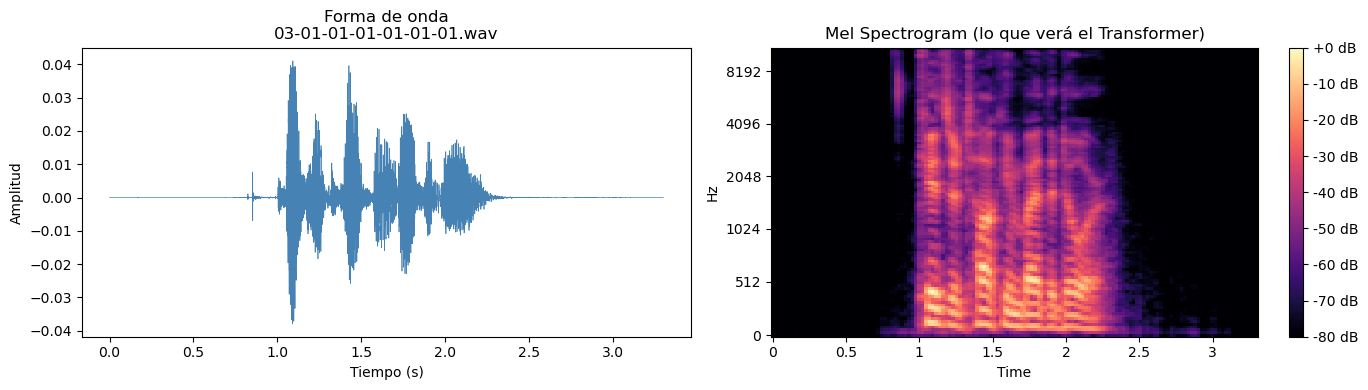

Forma del Mel Spectrogram: (128, 143)  → (n_mels=128, frames de tiempo)


In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Visualizar un audio de ejemplo y su Mel Spectrogram
sample_file = wav_files[0]
y_audio, sr = librosa.load(sample_file, sr=22050)

# Calcular Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Forma de onda
axes[0].plot(np.linspace(0, len(y_audio)/sr, len(y_audio)), y_audio, color='steelblue', linewidth=0.5)
axes[0].set_title(f'Forma de onda\n{os.path.basename(sample_file)}')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')

# Mel Spectrogram
img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Mel Spectrogram (lo que verá el Transformer)')

plt.tight_layout()
plt.show()

print(f"Forma del Mel Spectrogram: {mel_spec.shape}  → (n_mels=128, frames de tiempo)")

## 🔧 4. Imports y configuración general

In [6]:
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
import numpy as np
import librosa
import os
import glob
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# ── Configuración global ────────────────────────────────────────────────────
SR          = 22050   # sample rate
N_MELS      = 128     # número de bandas Mel  (equivale al alto del 'patch')
MAX_FRAMES  = 128     # frames temporales fijos (equivale al ancho de la imagen)
N_TOKENS    = 16      # número de franjas = tokens para el Transformer
                      # → cada token tendrá MAX_FRAMES//N_TOKENS * N_MELS features... 
                      #   pero simplificamos: 1 token = 1 franja de tiempo = N_MELS features
N_CLASSES   = 8       # 8 emociones
BATCH_SIZE  = 32

EMOTION_MAP = {
    '01': 0,  # neutral
    '02': 1,  # calm
    '03': 2,  # happy
    '04': 3,  # sad
    '05': 4,  # angry
    '06': 5,  # fearful
    '07': 6,  # disgust
    '08': 7,  # surprised
}

EMOTION_NAMES = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

print("Configuración lista ✅")
print(f"  Cada audio → Mel Spectrogram ({N_MELS} × {MAX_FRAMES})")
print(f"  Dividido en {N_TOKENS} franjas temporales (tokens)")
print(f"  Cada token tiene {N_MELS} features (bins Mel)")

Configuración lista ✅
  Cada audio → Mel Spectrogram (128 × 128)
  Dividido en 16 franjas temporales (tokens)
  Cada token tiene 128 features (bins Mel)


## 🎵 5. Función de extracción de features

**Analogía con MNIST:**  
- MNIST: imagen 28×28 → `unfold()` → 16 patches de 7×7  
- Audio: WAV → Mel Spectrogram 128×128 → split en columnas → **16 franjas de tiempo** (tokens)

In [7]:
def extract_mel_tokens(file_path, sr=SR, n_mels=N_MELS, max_frames=MAX_FRAMES, n_tokens=N_TOKENS):
    """
    Carga un archivo WAV y lo convierte en una secuencia de tokens.
    
    Retorna:
        tokens: numpy array de forma (n_tokens, n_mels)
                → equivale a los patches (16, 49) del código MNIST
    """
    # 1. Cargar audio
    y, _ = librosa.load(file_path, sr=sr, duration=3.0)  # máx 3 segundos
    
    # 2. Calcular Mel Spectrogram → forma (n_mels, frames)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)  # escala logarítmica (dB)
    
    # 3. Normalizar a [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    
    # 4. Ajustar a max_frames columnas (pad o recortar)
    if mel_db.shape[1] < max_frames:
        # Padding con ceros a la derecha
        pad = max_frames - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad)), mode='constant')
    else:
        mel_db = mel_db[:, :max_frames]  # recortar
    
    # 5. Dividir en n_tokens franjas temporales  ← ANALOGÍA CON unfold()
    #    mel_db tiene forma (128, 128)
    #    La dividimos en 16 franjas de 8 columnas cada una
    #    Luego promediamos cada franja → (16, 128)
    frames_per_token = max_frames // n_tokens  # = 8
    tokens = []
    for i in range(n_tokens):
        start = i * frames_per_token
        end   = start + frames_per_token
        token = mel_db[:, start:end].mean(axis=1)  # promedio temporal → (n_mels,)
        tokens.append(token)
    
    return np.array(tokens)  # forma final: (16, 128)


# Verificar con un ejemplo
test_tokens = extract_mel_tokens(wav_files[0])
print(f"Forma de los tokens: {test_tokens.shape}")
print(f"→ {test_tokens.shape[0]} tokens (franjas temporales)")
print(f"→ {test_tokens.shape[1]} features por token (bins Mel)")
print()
print("Comparación con MNIST:")
print(f"  MNIST  → patches.shape = (16, 49)   [16 patches de 7×7]")
print(f"  Audio  → tokens.shape  = (16, 128)  [16 franjas de Mel]")

c:\Users\luisc\.conda\envs\PT\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Forma de los tokens: (16, 128)
→ 16 tokens (franjas temporales)
→ 128 features por token (bins Mel)

Comparación con MNIST:
  MNIST  → patches.shape = (16, 49)   [16 patches de 7×7]
  Audio  → tokens.shape  = (16, 128)  [16 franjas de Mel]


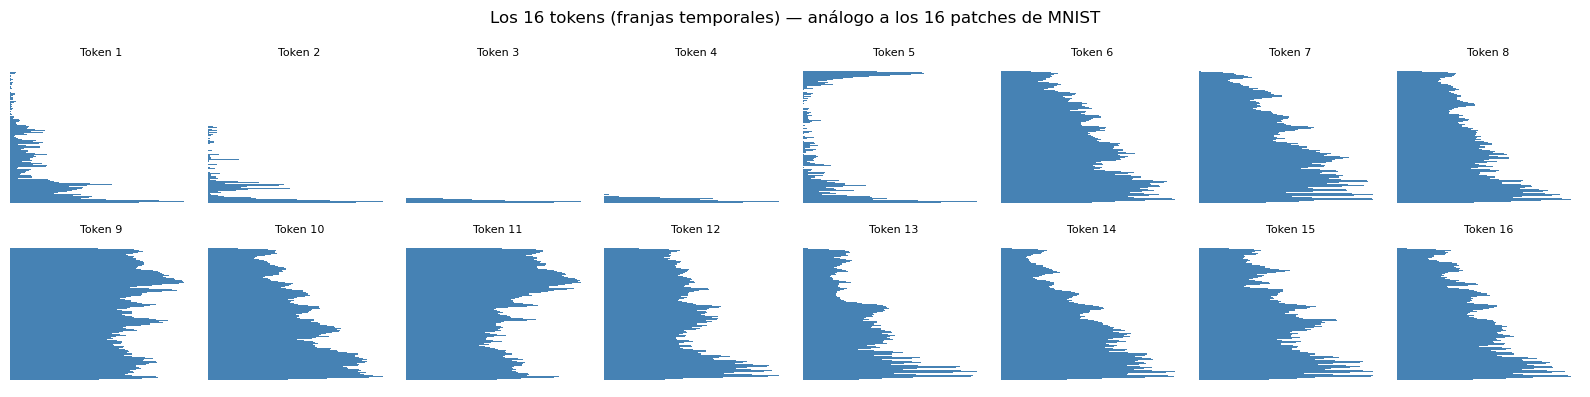

In [6]:
# Visualizar cómo se dividen los tokens
sample_tokens = extract_mel_tokens(wav_files[10])

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Los 16 tokens (franjas temporales) — análogo a los 16 patches de MNIST', fontsize=12)

for i in range(16):
    r, c = i // 8, i % 8
    ax = axes[r, c]
    ax.barh(range(N_MELS), sample_tokens[i], color='steelblue', height=1.0)
    ax.set_title(f'Token {i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 📂 6. Dataset y DataModule



In [8]:
# ── Cargar todos los archivos y extraer features ────────────────────────────
# 

print("Extrayendo features de todos los audios...")
X_all, y_all = [], []

for i, fp in enumerate(wav_files):
    parts = os.path.basename(fp).split('-')
    emotion_code = parts[2]
    label = EMOTION_MAP.get(emotion_code)
    if label is None:
        continue
    try:
        tokens = extract_mel_tokens(fp)  # (16, 128)
        X_all.append(tokens)
        y_all.append(label)
    except Exception as e:
        print(f"Error en {fp}: {e}")
    
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(wav_files)} archivos procesados...")

X_all = np.array(X_all, dtype=np.float32)  # (N, 16, 128)
y_all = np.array(y_all, dtype=np.int64)

print(f"\n✅ Listo!")
print(f"   X_all.shape = {X_all.shape}  → (muestras, tokens, features)")
print(f"   y_all.shape = {y_all.shape}")

Extrayendo features de todos los audios...
  100/2880 archivos procesados...
  200/2880 archivos procesados...
  300/2880 archivos procesados...
  400/2880 archivos procesados...
  500/2880 archivos procesados...
  600/2880 archivos procesados...
  700/2880 archivos procesados...
  800/2880 archivos procesados...
  900/2880 archivos procesados...
  1000/2880 archivos procesados...
  1100/2880 archivos procesados...
  1200/2880 archivos procesados...
  1300/2880 archivos procesados...
  1400/2880 archivos procesados...
  1500/2880 archivos procesados...
  1600/2880 archivos procesados...
  1700/2880 archivos procesados...
  1800/2880 archivos procesados...
  1900/2880 archivos procesados...
  2000/2880 archivos procesados...
  2100/2880 archivos procesados...
  2200/2880 archivos procesados...
  2300/2880 archivos procesados...
  2400/2880 archivos procesados...
  2500/2880 archivos procesados...
  2600/2880 archivos procesados...
  2700/2880 archivos procesados...
  2800/2880 archivos 

In [9]:
# ── Dataset ─────────────────────────────────────────────────────────────────
# IGUAL al código base, solo que X ya tiene forma (16, 128) en vez de (784,)

class AudioDataset(torch.utils.data.Dataset):
    """Dataset de audio con tokens de Mel Spectrogram.
    
    Cada muestra es una secuencia de 16 tokens de 128 features.
    Análogo al AttnDataset de MNIST con patches de 7×7.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, 16, 128)
        self.y = torch.tensor(y, dtype=torch.long)     # (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        # Retorna (16, 128) y label — igual que AttnDataset retornaba (16, 49) y label
        return self.X[ix], self.y[ix]


# ── DataModule ───────────────────────────────────────────────────────────────
class RAVDESSDataModule(pl.LightningDataModule):
    """
    DataModule para RAVDESS.
    Estructura idéntica a MNISTDataModule del código base.
    """
    def __init__(self, X, y, batch_size=BATCH_SIZE, test_size=0.2):
        super().__init__()
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.test_size = test_size

    def setup(self, stage=None):
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y,
            test_size=self.test_size,
            stratify=self.y,   # mantiene proporción de clases
            random_state=42
        )
        self.train_ds = AudioDataset(X_train, y_train)
        self.val_ds   = AudioDataset(X_test,  y_test)
        print(f"Train: {len(self.train_ds)} | Val: {len(self.val_ds)}")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True,  num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.val_ds,   batch_size=self.batch_size, shuffle=False, num_workers=0)


# Instanciar y verificar
dm = RAVDESSDataModule(X_all, y_all)
dm.setup()

sample_x, sample_y = next(iter(dm.train_dataloader()))
print(f"\nBatch shape: {sample_x.shape}  → (batch, tokens, features)")
print(f"Labels shape: {sample_y.shape}")

Train: 2304 | Val: 576

Batch shape: torch.Size([32, 16, 128])  → (batch, tokens, features)
Labels shape: torch.Size([32])


## 🤖 7. Modelo Transformer 

Las clases `MultiHeadAttention`, `TransformerBlock` y `Model`  
Solo cambian los **hiperparámetros de entrada** para adaptarse al audio.

```
MNIST:  n_input=49,  seq_len=16, n_embd=49,  n_classes=10
Audio:  n_input=128, seq_len=16, n_embd=128, n_classes=8
```

In [10]:
import math

# ── MultiHeadAttention ───────────────────────────────────────────────────────
# IGUAL al código base — sin cambios
class MultiHeadAttention(torch.nn.Module):
    """
    Multi-Head Attention.
    Cada 'cabeza' aprende a atender distintos patrones:
      - una cabeza puede enfocarse en el tono
      - otra en el ritmo o la energía
      - otra en cambios abruptos (ira vs calma)
    """
    def __init__(self, n_embd, n_heads):
        super().__init__()
        self.n_heads = n_heads

        # Proyecciones key, query, value
        self.key   = torch.nn.Linear(n_embd, n_embd * n_heads)
        self.query = torch.nn.Linear(n_embd, n_embd * n_heads)
        self.value = torch.nn.Linear(n_embd, n_embd * n_heads)

        # Proyección de salida
        self.proj = torch.nn.Linear(n_embd * n_heads, n_embd)

    def forward(self, x):
        B, L, D = x.size()  # (batch, seq_len=16, features=128)

        k = self.key(x).view(B, L, D, self.n_heads).transpose(1, 3)   # (B, nh, L, D)
        q = self.query(x).view(B, L, D, self.n_heads).transpose(1, 3) # (B, nh, L, D)
        v = self.value(x).view(B, L, D, self.n_heads).transpose(1, 3) # (B, nh, L, D)

        # Attention scores
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)  # (B, nh, L, L)
        y   = att @ v                 # (B, nh, L, D)

        y = y.transpose(1, 2).contiguous().view(B, L, D * self.n_heads)
        return self.proj(y)


# ── TransformerBlock ─────────────────────────────────────────────────────────
# IGUAL al código base — sin cambios
class TransformerBlock(torch.nn.Module):
    """
    Bloque completo: LayerNorm + MultiHeadAttention + LayerNorm + MLP (FFN)
    Conexiones residuales (skip connections) en ambos sub-bloques.
    """
    def __init__(self, n_embd, n_heads):
        super().__init__()
        self.ln1  = torch.nn.LayerNorm(n_embd)
        self.ln2  = torch.nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_heads)
        self.mlp  = torch.nn.Sequential(
            torch.nn.Linear(n_embd, 4 * n_embd),
            torch.nn.GELU(),                        # GELU en vez de ReLU (más estable)
            torch.nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        x = self.ln1(x + self.attn(x))  # Attention + residual
        x = self.ln2(x + self.mlp(x))   # FFN + residual
        return x


# ── AudioTransformer ─────────────────────────────────────────────────────────
# ADAPTADO del Model del código base
class AudioTransformer(pl.LightningModule):
    """
    Transformer para clasificación de emociones en audio.
    
    Cambios respecto al código base:
      - n_input:  49 (7×7 patch)  → 128 (bins Mel)
      - seq_len:  16              → 16 (mismo número de tokens)
      - n_embd:   49              → 128
      - n_heads:  16              → 4  (reducido para audio)
      - fc final: 10 clases       → 8 emociones
      - Añadido: Dropout para regularización
    """
    def __init__(
        self,
        n_input   = N_MELS,       # 128 features por token
        n_embd    = N_MELS,       # 128 dimensión del embedding
        seq_len   = N_TOKENS,     # 16 tokens
        n_heads   = 4,            # 4 cabezas de atención
        n_layers  = 3,            # 3 bloques Transformer
        n_classes = N_CLASSES,    # 8 emociones
        dropout   = 0.1,
        lr        = 3e-4,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        # Embedding de entrada: proyecta cada token al espacio n_embd
        # Análogo a inp_emb del código base
        self.inp_emb = torch.nn.Linear(n_input, n_embd)

        # Embedding posicional: le dice al modelo el orden temporal
        # IGUAL al código base (pos_emb)
        self.pos_emb = torch.nn.Parameter(torch.zeros(1, seq_len, n_embd))

        self.dropout = torch.nn.Dropout(dropout)

        # Bloques Transformer apilados 
        self.transformer = torch.nn.Sequential(
            *[TransformerBlock(n_embd, n_heads) for _ in range(n_layers)]
        )

        # Clasificador final
        # MNIST: Linear(49*16, 10) → Audio: Linear(128*16, 8)
        self.fc = torch.nn.Linear(n_embd * seq_len, n_classes)

        # Inicialización del embedding posicional
        torch.nn.init.trunc_normal_(self.pos_emb, std=0.02)

    def forward(self, x):
        # x: (B, 16, 128) — batch de secuencias de tokens
        
        # 1. Embedding de entrada + posicional
        e = self.inp_emb(x) + self.pos_emb  # (B, 16, 128)
        e = self.dropout(e)
        
        # 2. Pasar por los bloques Transformer (MultiHeadAttention + FFN)
        z = self.transformer(e)              # (B, 16, 128)
        
        # 3. Aplanar y clasificar
        y = self.fc(z.view(z.size(0), -1))   # (B, 8)
        return y

    def predict(self, x):
        with torch.no_grad():
            return torch.argmax(self(x), dim=1)

    def compute_loss_and_acc(self, batch):
        x, y = batch
        y_hat = self(x)
        loss  = F.cross_entropy(y_hat, y)
        acc   = (torch.argmax(y_hat, dim=1) == y).float().mean().item()
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self.compute_loss_and_acc(batch)
        self.log('loss',     loss, prog_bar=True)
        self.log('acc',      acc,  prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self.compute_loss_and_acc(batch)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  acc,  prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


# Verificar que el modelo corre
model = AudioTransformer(n_layers=3)
test_out = model(sample_x)
print(f"Input shape:  {sample_x.shape}")
print(f"Output shape: {test_out.shape}  → (batch, 8 emociones)")
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}")

Input shape:  torch.Size([32, 16, 128])
Output shape: torch.Size([32, 8])  → (batch, 8 emociones)

Parámetros totales: 1,223,048


## 🏋️ 8. Entrenamiento

## 📊 9. Evaluación y visualización de resultados

In [11]:
# ── Sección 8: Entrenamiento + Métricas ──────────────────────────────────────
from pytorch_lightning.callbacks import Callback

class MetricsLogger(Callback):
    def __init__(self):
        self.train_loss = []
        self.val_loss   = []
        self.train_acc  = []
        self.val_acc    = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('loss',     torch.tensor(0)).item())
        self.train_acc.append( trainer.callback_metrics.get('acc',      torch.tensor(0)).item())

    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(trainer.callback_metrics.get('val_loss',   torch.tensor(0)).item())
        self.val_acc.append( trainer.callback_metrics.get('val_acc',    torch.tensor(0)).item())


metrics_cb = MetricsLogger()

model   = AudioTransformer(n_layers=3, n_heads=4, dropout=0.1)
trainer = pl.Trainer(
    max_epochs=20,
    logger=None,
    enable_checkpointing=False,
    callbacks=[metrics_cb],
)
trainer.fit(model, dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Train: 2304 | Val: 576



  | Name         | Type       | Params | Mode 
----------------------------------------------------
0 | inp_emb      | Linear     | 16.5 K | train
1 | dropout      | Dropout    | 0      | train
2 | transformer  | Sequential | 1.2 M  | train
3 | fc           | Linear     | 16.4 K | train
  | other params | n/a        | 2.0 K  | n/a  
----------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.892     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\luisc\.conda\envs\PT\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\luisc\.conda\envs\PT\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 72/72 [00:02<00:00, 33.01it/s, v_num=0, loss=0.000946, acc=1.000, val_loss=0.134, val_acc=0.958]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 72/72 [00:02<00:00, 32.94it/s, v_num=0, loss=0.000946, acc=1.000, val_loss=0.134, val_acc=0.958]


 Época Train Loss Val Loss Train Acc Val Acc
     1     1.6329   1.6499    0.4375  0.3733
     2     1.4178   1.4074    0.3750  0.4913
     3     0.9439   1.1444    0.7500  0.5729
     4     0.8156   0.8910    0.6875  0.6719
     5     0.5634   0.8116    0.7812  0.7188
     6     0.3411   0.4862    0.9688  0.8160
     7     0.2666   0.3965    0.8750  0.8611
     8     0.1331   0.3384    1.0000  0.8872
     9     0.0735   0.2598    0.9688  0.9010
    10     0.0483   0.1851    1.0000  0.9444
    11     0.0269   0.1968    1.0000  0.9306
    12     0.0360   0.1705    1.0000  0.9462
    13     0.0416   0.1752    1.0000  0.9583
    14     0.0265   0.2050    1.0000  0.9497
    15     0.0350   0.1805    1.0000  0.9444
    16     0.0043   0.1233    1.0000  0.9549
    17     0.0023   0.1359    1.0000  0.9549
    18     0.0013   0.1379    1.0000  0.9549
    19     0.0061   0.1366    1.0000  0.9583
    20     0.0009   0.1341    1.0000  0.9583


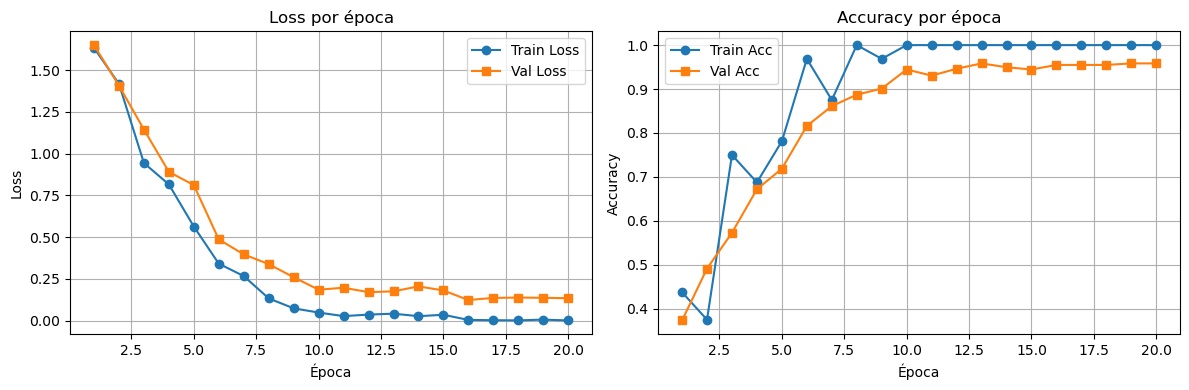

In [12]:
import pandas as pd

# Igualar longitudes — el sanity check agrega un val extra al inicio
train_loss = metrics_cb.train_loss
val_loss   = metrics_cb.val_loss[-len(train_loss):]  # recortar al mismo tamaño
train_acc  = metrics_cb.train_acc
val_acc    = metrics_cb.val_acc[-len(train_acc):]

n_epochs = len(train_loss)

df = pd.DataFrame({
    'Época'      : range(1, n_epochs + 1),
    'Train Loss' : [f"{v:.4f}" for v in train_loss],
    'Val Loss'   : [f"{v:.4f}" for v in val_loss],
    'Train Acc'  : [f"{v:.4f}" for v in train_acc],
    'Val Acc'    : [f"{v:.4f}" for v in val_acc],
})
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, n_epochs+1), train_loss, label='Train Loss', marker='o')
axes[0].plot(range(1, n_epochs+1), val_loss,   label='Val Loss',   marker='s')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, n_epochs+1), train_acc, label='Train Acc', marker='o')
axes[1].plot(range(1, n_epochs+1), val_acc,   label='Val Acc',   marker='s')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

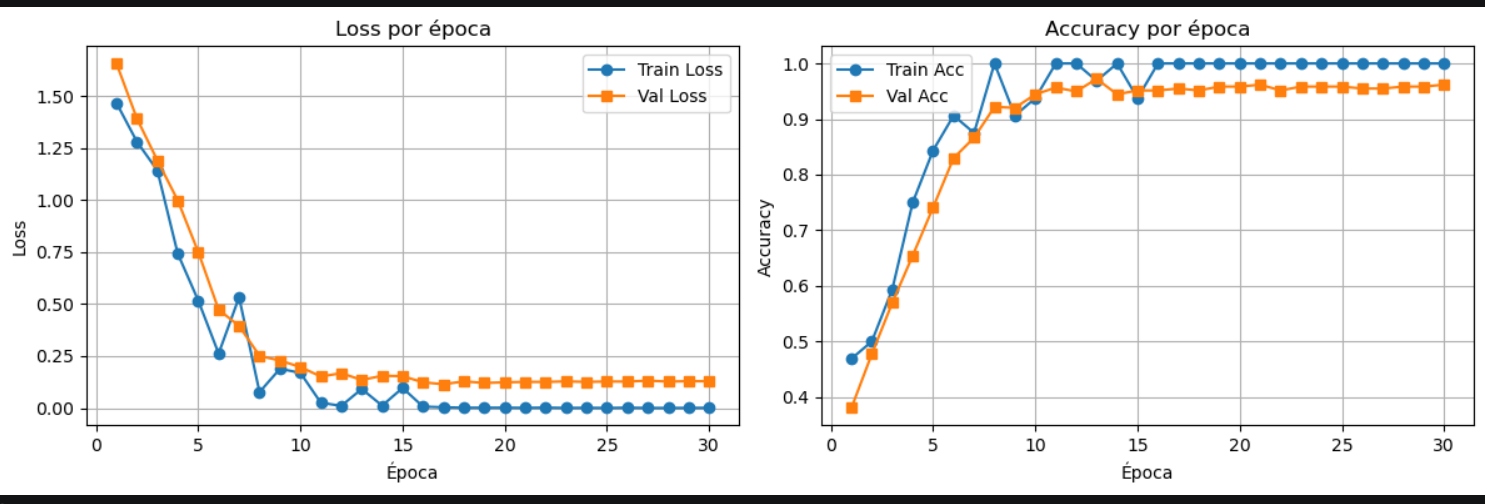

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener predicciones en validación
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x_batch, y_batch in dm.val_dataloader():
        preds = model.predict(x_batch)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
print(f"Accuracy en validación: {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(all_labels, all_preds, target_names=EMOTION_NAMES))

Accuracy en validación: 0.9583 (95.83%)

              precision    recall  f1-score   support

     neutral       0.95      1.00      0.97        38
        calm       0.95      0.97      0.96        76
       happy       1.00      0.97      0.99        77
         sad       0.92      0.92      0.92        77
       angry       0.97      0.97      0.97        77
     fearful       0.95      0.97      0.96        77
     disgust       0.95      0.92      0.93        77
   surprised       0.97      0.95      0.96        77

    accuracy                           0.96       576
   macro avg       0.96      0.96      0.96       576
weighted avg       0.96      0.96      0.96       576



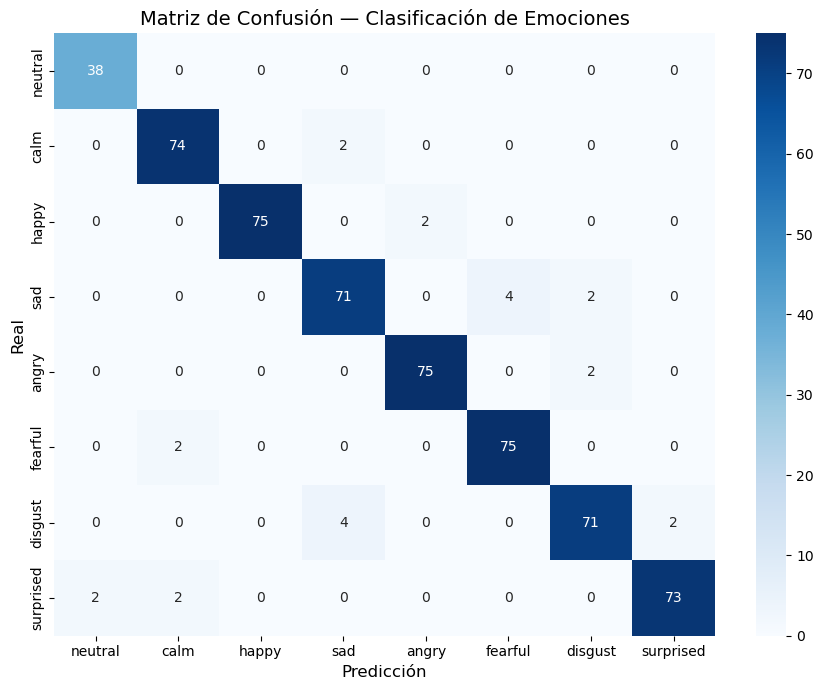

In [18]:
# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real',       fontsize=12)
ax.set_title('Matriz de Confusión — Clasificación de Emociones', fontsize=14)
plt.tight_layout()
plt.show()

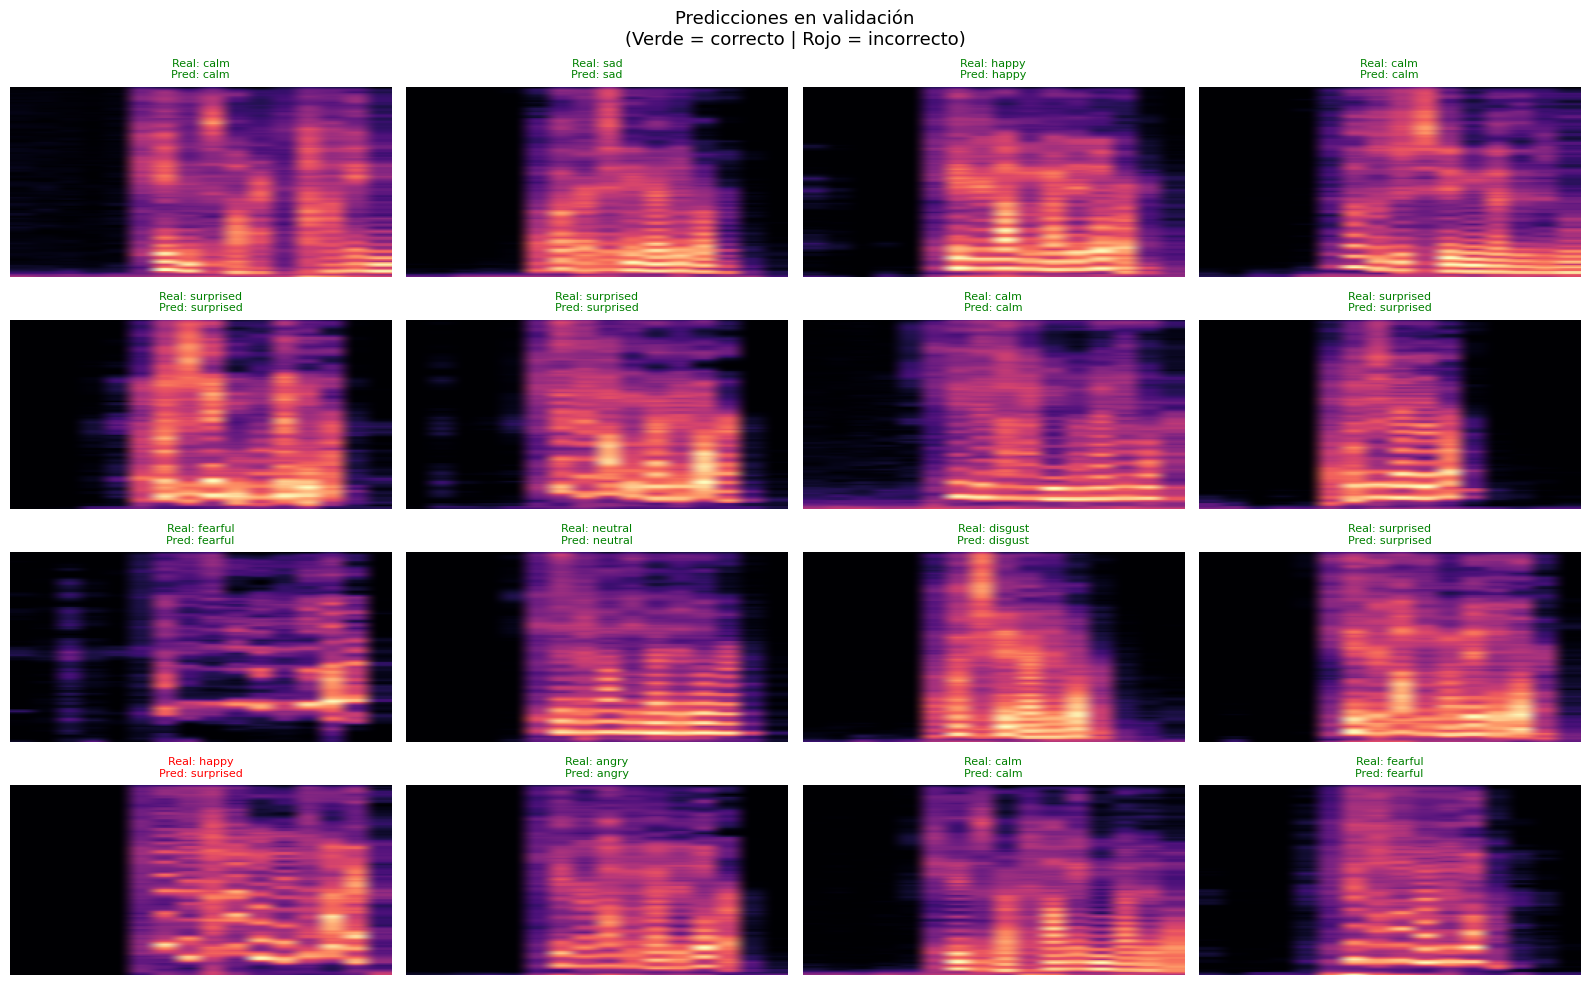

In [15]:
# Visualizar predicciones individuales — análogo a la celda final del código base
import random

val_x, val_y = next(iter(dm.val_dataloader()))
preds = model.predict(val_x)

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
fig.suptitle('Predicciones en validación\n(Verde = correcto | Rojo = incorrecto)', fontsize=13)

indices = random.sample(range(len(val_x)), 16)

for idx, ax_idx in enumerate(indices):
    r, c = idx // 4, idx % 4
    ax = axes[r, c]
    
    tokens = val_x[ax_idx].numpy()  # (16, 128)
    label  = val_y[ax_idx].item()
    pred   = preds[ax_idx].item()
    
    # Reconstruir el spectrogram desde los tokens como imagen 16×128
    ax.imshow(tokens.T, aspect='auto', cmap='magma', origin='lower')
    ax.axis('off')
    
    color = 'green' if label == pred else 'red'
    ax.set_title(
        f'Real: {EMOTION_NAMES[label]}\nPred: {EMOTION_NAMES[pred]}',
        color=color, fontsize=8
    )

plt.tight_layout()
plt.show()

## 📝 Resumen — ¿Qué cambió del código base?

| Componente | Código base (MNIST) | Este notebook (RAVDESS) |
|---|---|---|
| **Dataset** | MNIST 28×28 imágenes | RAVDESS audios .wav |
| **Tokenización** | `unfold()` → 16 patches 7×7 | `librosa` → 16 franjas Mel |
| **Token shape** | `(16, 49)` | `(16, 128)` |
| **n_input** | 49 | 128 |
| **n_embd** | 49 | 128 |
| **n_classes** | 10 | 8 |


**La arquitectura Transformer no cambió — solo la forma de representar los datos como secuencia de tokens.**

In [20]:
torch.save(model.state_dict(), "modelo_emociones.pth")

In [17]:
model.eval()

tokens = extract_mel_tokens("Alegre.m4a")

x = torch.tensor(tokens, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    output = model(x)
    pred = torch.argmax(output, dim=1).item()

print("Predicción:", EMOTION_NAMES[pred])

C:\Users\luisc\AppData\Local\Temp\ipykernel_31092\1363476934.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr, duration=3.0)  # máx 3 segundos


Predicción: sad
